# Workflow Sequence Recommendation using DAG-aware Models

Этот ноутбук содержит полную реализацию и сравнение моделей для рекомендации продолжения workflow sequences в направленных ациклических графах (DAG).



<a id="установка"></a>
## Установка зависимостей


In [ ]:
# Установка необходимых библиотек (раскомментируйте если нужно)
!pip install torch torch-geometric networkx numpy scikit-learn scipy pandas matplotlib seaborn

In [ ]:
import json
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Добавляем путь к модулям
sys.path.insert(0, os.getcwd())

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ndcg_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт функций из наших модулей
from directed_dag_models import (
    load_dag_from_json,
    extract_paths_from_compositions,
    create_training_pairs,
    split_data,
    build_graph,
    prepare_pyg,
    prepare_sequences,
    build_composition_graphs,
    popularity_baseline,
    SRGNNRecommender,
    GRU4Rec,
    train_srgnn_global_graph,
    train_gru_model,
    compute_metrics,
    build_global_srgnn_adj,
    build_srgnn_samples_from_contexts
)

from dag_transformer_integration import add_dag_transformer_to_main
from modern_sequence_models import (
    prepare_sequence_model_data,
    prepare_incremental_graph_model_data,
    build_successor_service_map,
    run_srgnn_graph_experiment,
    run_graph_transformer_experiment,
    run_graph_transformer_graph_experiment,
    run_sasrec_experiment,
    run_gpt_experiment,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


<a id="подготовка-данных"></a>
## Подготовка данных

Загружаем данные из JSON файла и преобразуем их в формат, подходящий для обучения моделей.


In [ ]:
# Параметры эксперимента
EPOCHS = 150  # Для production рекомендуется 150+
MAX_LEN = 20  # Максимальная длина последовательности
HIDDEN_DIM = 64  # Размерность скрытого слоя
DROPOUT = 0.4
LEARNING_RATE = 1e-3
TEST_SIZE = 0.3
SEED = 42
BATCH_SIZE = 32
DATA_FILE = "compositionsDAG.json"

# Устанавливаем seed для воспроизводимости
torch.manual_seed(SEED)
np.random.seed(SEED)

print("="*70)
print("ПАРАМЕТРЫ ЭКСПЕРИМЕНТА")
print("="*70)
print(f"Эпох: {EPOCHS}")
print(f"Max длина последовательности: {MAX_LEN}")
print(f"Hidden dimension: {HIDDEN_DIM}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Test size: {TEST_SIZE}")
print("="*70)

ПАРАМЕТРЫ ЭКСПЕРИМЕНТА
Эпох: 150
Max длина последовательности: 20
Hidden dimension: 64
Dropout: 0.4
Learning rate: 0.001
Test size: 0.3


In [ ]:
# Загрузка и подготовка данных
dag, compositions = load_dag_from_json(Path(DATA_FILE))
paths_with_idx = extract_paths_from_compositions(compositions)
contexts, targets, comp_indices = create_training_pairs(paths_with_idx)

print(f"Загружено композиций: {len(compositions)}")
print(f"Извлечено путей: {len(paths_with_idx)}")
print(f"Создано training pairs: {len(contexts)}")

# Разделение на train/test
ctx_train, ctx_test, y_train, y_test, comp_train_idx, comp_test_idx = split_data(
    contexts, targets, comp_indices, TEST_SIZE, SEED
)

print(f"\nTrain set: {len(ctx_train)} samples ({len(ctx_train)/len(contexts)*100:.1f}%)")
print(f"Test set: {len(ctx_test)} samples ({len(ctx_test)/len(contexts)*100:.1f}%)")

# Построение графа
train_comp_set = set(comp_train_idx)
train_paths_only = [path for path, comp_idx in paths_with_idx if comp_idx in train_comp_set]
all_nodes = sorted({node for path, _ in paths_with_idx for node in path})

# Строим оригинальный граф для GRU4Rec
original_graph = build_graph(train_paths_only)
original_graph.add_nodes_from(all_nodes)

# Обрабатываем циклы для DAG-Transformer
from cycle_handling import build_dag_from_paths
graph = build_dag_from_paths(train_paths_only, cycle_handling="remove_weakest")
graph.add_nodes_from(all_nodes)

nodes = sorted(graph.nodes())
data_pyg, node_map = prepare_pyg(graph, nodes)

services = sorted({y for y in targets})
service_map = {svc: idx for idx, svc in enumerate(services)}

print(f"\nУзлов в графе: {len(nodes)}")
print(f"Ребер в графе: {graph.number_of_edges()}")
print(f"Уникальных сервисов: {len(services)}")

# Подготовка данных для обучения
targets_train_tensor = torch.tensor([service_map[y] for y in y_train], dtype=torch.long)
targets_test_tensor = torch.tensor([service_map[y] for y in y_test], dtype=torch.long)
train_idx = torch.tensor([node_map[ctx[-1]] for ctx in ctx_train], dtype=torch.long)
test_idx = torch.tensor([node_map[ctx[-1]] for ctx in ctx_test], dtype=torch.long)
targets_train = torch.tensor([service_map[y] for y in y_train], dtype=torch.long)
targets_test = torch.tensor([service_map[y] for y in y_test], dtype=torch.long)
train_target_indices = [service_map[y] for y in y_train]
test_target_indices = [service_map[y] for y in y_test]
service_node_indices = torch.tensor([node_map[svc] + 1 for svc in services], dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

Загружено композиций: 943
Извлечено путей: 943
Создано training pairs: 1016

Train set: 711 samples (70.0%)
Test set: 305 samples (30.0%)

Узлов в графе: 50
Ребер в графе: 87
Уникальных сервисов: 15

Device: cuda


<a id="модель-1"></a>
# МОДЕЛЬ 1: Popularity Baseline

Простая базовая модель, которая предсказывает самый популярный сервис.


In [ ]:
print("="*70)
print("МОДЕЛЬ 1: POPULARITY BASELINE")
print("="*70)

baseline_results = popularity_baseline(
    targets_train_tensor,
    targets_test_tensor,
    len(service_map),
    name="Popularity"
)

print(f"Результаты Popularity Baseline:")
print(f"Accuracy: {baseline_results['accuracy']:.4f}")
print(f"NDCG@10: {baseline_results['ndcg']:.4f}")
print(f"F1-Score: {baseline_results['f1']:.4f}")
print(f"Precision: {baseline_results['precision']:.4f}")
print(f"Recall: {baseline_results['recall']:.4f}")

МОДЕЛЬ 1: POPULARITY BASELINE
Результаты Popularity Baseline:
Accuracy: 0.4787
NDCG@10: 0.6106
F1-Score: 0.0540
Precision: 0.0399
Recall: 0.0833


<a id="модель-2"></a>
# МОДЕЛЬ 2: SR-GNN

**Session-based Recommendation with Graph Neural Networks** (Wu et al., AAAI 2019)

SR-GNN использует графовые нейронные сети для моделирования сессий пользователей.

### Архитектура:
- **Session Graph Construction**: Каждая сессия преобразуется в направленный граф
- **GNN Layer**: GRU-подобная ячейка с 3 гейтами (reset, input, new)
- **Session Representation**: Attention mechanism для агрегации элементов сессии
- **Prediction**: Dot product session representation с embeddings всех items


In [ ]:
print("="*70)
print("МОДЕЛЬ 2: SR-GNN")
print("Session-based Recommendation with Graph Neural Networks")
print("Wu et al., AAAI 2019")
print("="*70)

# Создание модели SR-GNN
srgnn_model = SRGNNRecommender(
    num_nodes=len(node_map),
    hidden=128,
    step=1,
    non_hybrid=False
)
srgnn_optimizer = torch.optim.Adam(srgnn_model.parameters(), lr=5e-4)

print("\nНачало обучения SR-GNN...")
srgnn_results = train_srgnn_global_graph(
    srgnn_model,
    node_map,
    data_pyg,
    ctx_train,
    ctx_test,
    train_target_indices,
    test_target_indices,
    service_node_indices,
    srgnn_optimizer,
    EPOCHS,
    "SR-GNN",
    device
)

print(f"Результаты SR-GNN:")
print(f"Accuracy: {srgnn_results['accuracy']:.4f}")
print(f"NDCG@10: {srgnn_results['ndcg']:.4f}")
print(f"F1-Score: {srgnn_results['f1']:.4f}")
print(f"Precision: {srgnn_results['precision']:.4f}")
print(f"Recall: {srgnn_results['recall']:.4f}")

МОДЕЛЬ 2: SR-GNN
Session-based Recommendation with Graph Neural Networks
Wu et al., AAAI 2019

Начало обучения SR-GNN...
Результаты SR-GNN:
Accuracy: 0.5410
NDCG@10: 0.7761
F1-Score: 0.3385
Precision: 0.3148
Recall: 0.3779


<a id="модель-3"></a>
# МОДЕЛЬ 3: GRU4Rec

**Session-based Recommendations with Recurrent Neural Networks** (Hidasi et al., ICLR 2016)

GRU4Rec использует рекуррентные нейронные сети (GRU) для моделирования последовательностей.

### Архитектура:
- **Embedding Layer**: Embedding для items с отдельным dropout (0.25)
- **GRU Layer**: Многослойный GRU с dropout только между слоями
- **Output Layer**: Linear layer для предсказания следующего item
- **DAG Masking**: Маскирование выходов по структуре DAG (уникальная добавка)


In [ ]:
print("="*70)
print("МОДЕЛЬ 3: GRU4Rec")
print("Session-based Recommendations with Recurrent Neural Networks")
print("Hidasi et al., ICLR 2016")
print("="*70)

# Подготовка данных для всех sequential-моделей на ОДНОМ split
print("\nПодготовка данных для GRU4Rec и Transformer-бейзлайнов...")
sequence_train_data = prepare_sequence_model_data(
    ctx_train, y_train, node_map, service_map, max_len=MAX_LEN
)
sequence_test_data = prepare_sequence_model_data(
    ctx_test, y_test, node_map, service_map, max_len=MAX_LEN
)

seq_train = sequence_train_data["input_ids"]
seq_test = sequence_test_data["input_ids"]
len_train = sequence_train_data["lengths"]
len_test = sequence_test_data["lengths"]
lab_train = sequence_train_data["targets"]
lab_test = sequence_test_data["targets"]
last_nodes_train = sequence_train_data["last_node_ids"]
last_nodes_test = sequence_test_data["last_node_ids"]

# Дополнительно готовим инкрементальные подграфы для graph-вариантов
train_comp_graph_indices = sorted(set(comp_train_idx))
test_comp_graph_indices = sorted(set(comp_test_idx))
graph_train_samples = prepare_incremental_graph_model_data(
    compositions, train_comp_graph_indices, node_map, service_map
)
graph_test_samples = prepare_incremental_graph_model_data(
    compositions, test_comp_graph_indices, node_map, service_map
)
print(f"Подготовлено graph-train samples: {len(graph_train_samples)}")
print(f"Подготовлено graph-test samples: {len(graph_test_samples)}")

# Построение successor-структур из исходного train-графа
successors = build_successor_service_map(original_graph, node_map, service_map)
successor_nodes = defaultdict(list)
for u, v in original_graph.edges():
    if u in node_map and v in node_map:
        successor_nodes[node_map[u]].append(node_map[v])

# Создание модели GRU4Rec
gru_model = GRU4Rec(
    num_nodes=len(node_map),
    num_services=len(service_map),
    embedding_dim=64,
    hidden=HIDDEN_DIM * 2,
    num_layers=2,
    dropout_embed=0.25,
    dropout_hidden=0.4,
    dag_successors=successors,
    dag_successor_nodes=successor_nodes
)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

print("Начало обучения GRU4Rec...")
gru_results = train_gru_model(
    gru_model, seq_train, len_train, seq_test, len_test,
    lab_train, lab_test, last_nodes_train, last_nodes_test,
    gru_optimizer, EPOCHS, loss_type='ce', n_sample=0, sample_alpha=0.75
)

print(f"\nРезультаты GRU4Rec:")
print(f"Accuracy: {gru_results['accuracy']:.4f}")
print(f"NDCG@10: {gru_results['ndcg']:.4f}")
print(f"F1-Score: {gru_results['f1']:.4f}")
print(f"Precision: {gru_results['precision']:.4f}")
print(f"Recall: {gru_results['recall']:.4f}")

МОДЕЛЬ 3: GRU4Rec
Session-based Recommendations with Recurrent Neural Networks
Hidasi et al., ICLR 2016

Подготовка данных для GRU4Rec и Transformer-бейзлайнов...
Подготовлено graph-train samples: 738
Подготовлено graph-test samples: 332
Начало обучения GRU4Rec...

Результаты GRU4Rec:
Accuracy: 0.5475
NDCG@10: 0.7700
F1-Score: 0.3439
Precision: 0.3851
Recall: 0.3905


<a id="модель-4"></a>
# МОДЕЛЬ 4: DAG-Transformer

**Transformer-based model with DAG-aware attention mechanism**

DAG-Transformer использует архитектуру Transformer с учетом структуры DAG через специальные механизмы внимания.

### Архитектура:
- **Depth-Aware Embedding**: Node embeddings с учетом глубины узла в DAG
- **Topological Positional Encoding**: Позиционное кодирование на основе топологического порядка
- **DAG-Aware Attention Mask**: Attention mask разрешает внимание только к предшественникам
- **Transformer Blocks**: Multi-head self-attention с feed-forward сетями
- **Output Head**: Предсказание следующего сервиса


In [ ]:
# print("="*70)
# print("МОДЕЛЬ 4: DAG-Transformer")
# print("Transformer-based model with DAG-aware attention mechanism")
# print("="*70)

# class Args:
#     def __init__(self):
#         self.max_len = MAX_LEN
#         self.hidden = HIDDEN_DIM
#         self.dropout = DROPOUT
#         self.epochs = 200
#         self.lr = LEARNING_RATE

# args = Args()

# print("Начало обучения DAG-Transformer...")
# dag_transformer_results = add_dag_transformer_to_main(
#     ctx_train, ctx_test, y_train, y_test,
#     node_map, service_map, data_pyg, args, device,
#     graph=graph, original_graph=original_graph
# )

# print(f"\nРезультаты DAG-Transformer:")
# print(f"Accuracy: {dag_transformer_results['accuracy']:.4f}")
# print(f"NDCG@10: {dag_transformer_results['ndcg']:.4f}")
# print(f"F1-Score: {dag_transformer_results['f1']:.4f}")
# print(f"Precision: {dag_transformer_results['precision']:.4f}")
# print(f"Recall: {dag_transformer_results['recall']:.4f}")

<a id="модель-5"></a>
# МОДЕЛЬ 5: Graph Transformer

**Graph-aware Transformer for workflow recommendation**

Graph Transformer использует self-attention с дополнительным структурным bias, зависящим от расстояний между узлами в глобальном workflow-графе.

### Архитектура:
- **Node + Position Embeddings**: эмбеддинги узлов и позиций в последовательности
- **Graph Relation Bias**: bias в attention по кратчайшим путям в графе
- **Transformer Blocks**: multi-head self-attention с графовой структурой
- **Output Head**: предсказание следующего сервиса по representation последнего шага


In [ ]:
print("="*70)
print("МОДЕЛЬ 5: Graph Transformer")
print("Graph-aware Transformer for workflow recommendation")
print("="*70)

print("Начало обучения Graph Transformer...")
graph_transformer_results = run_graph_transformer_experiment(
    train_data=sequence_train_data,
    test_data=sequence_test_data,
    graph=graph,
    node_map=node_map,
    service_map=service_map,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(f"\nРезультаты Graph Transformer:")
print(f"Accuracy: {graph_transformer_results['accuracy']:.4f}")
print(f"NDCG@10: {graph_transformer_results['ndcg']:.4f}")
print(f"F1-Score: {graph_transformer_results['f1']:.4f}")
print(f"Precision: {graph_transformer_results['precision']:.4f}")
print(f"Recall: {graph_transformer_results['recall']:.4f}")

МОДЕЛЬ 5: Graph Transformer
Graph-aware Transformer for workflow recommendation
Начало обучения Graph Transformer...
Graph Transformer Epoch 1/150, Loss: 5.1822
Graph Transformer Epoch 10/150, Loss: 1.6156
Graph Transformer Epoch 20/150, Loss: 1.4020
Graph Transformer Epoch 30/150, Loss: 1.3346
Graph Transformer Epoch 40/150, Loss: 1.2873
Graph Transformer Epoch 50/150, Loss: 1.3457
Graph Transformer Epoch 60/150, Loss: 1.2512
Graph Transformer Epoch 70/150, Loss: 1.1899
Graph Transformer Epoch 80/150, Loss: 1.2899
Graph Transformer Epoch 90/150, Loss: 1.2239
Graph Transformer Epoch 100/150, Loss: 1.2160
Graph Transformer Epoch 110/150, Loss: 1.2088
Graph Transformer Epoch 120/150, Loss: 1.1946
Graph Transformer Epoch 130/150, Loss: 1.1893
Graph Transformer Epoch 140/150, Loss: 1.1718
Graph Transformer Epoch 150/150, Loss: 1.1810

Результаты Graph Transformer:
Accuracy: 0.5311
NDCG@10: 0.7738
F1-Score: 0.3493
Precision: 0.4008
Recall: 0.4004


<a id="модель-6"></a>
# МОДЕЛЬ 6: SASRec

**Self-Attentive Sequential Recommendation** (Kang and McAuley, ICDM 2018)

SASRec моделирует последовательность как autoregressive self-attention encoder с causal mask.

### Архитектура:
- **Item Embeddings**: эмбеддинги узлов последовательности
- **Learnable Positional Embeddings**: позиционная информация внутри сессии
- **Causal Self-Attention**: каждый шаг видит только прошлые элементы
- **Prediction Head**: предсказание следующего сервиса по последнему скрытому состоянию


In [ ]:
print("="*70)
print("МОДЕЛЬ 6: SASRec")
print("Self-Attentive Sequential Recommendation")
print("Kang and McAuley, ICDM 2018")
print("="*70)

print("Начало обучения SASRec...")
sasrec_results = run_sasrec_experiment(
    train_data=sequence_train_data,
    test_data=sequence_test_data,
    node_map=node_map,
    service_map=service_map,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(f"\nРезультаты SASRec:")
print(f"Accuracy: {sasrec_results['accuracy']:.4f}")
print(f"NDCG@10: {sasrec_results['ndcg']:.4f}")
print(f"F1-Score: {sasrec_results['f1']:.4f}")
print(f"Precision: {sasrec_results['precision']:.4f}")
print(f"Recall: {sasrec_results['recall']:.4f}")

МОДЕЛЬ 6: SASRec
Self-Attentive Sequential Recommendation
Kang and McAuley, ICDM 2018
Начало обучения SASRec...
SASRec Epoch 1/150, Loss: 6.1085
SASRec Epoch 10/150, Loss: 1.7264
SASRec Epoch 20/150, Loss: 1.4408
SASRec Epoch 30/150, Loss: 1.3636
SASRec Epoch 40/150, Loss: 1.3274
SASRec Epoch 50/150, Loss: 1.2890
SASRec Epoch 60/150, Loss: 1.2859
SASRec Epoch 70/150, Loss: 1.2553
SASRec Epoch 80/150, Loss: 1.2842
SASRec Epoch 90/150, Loss: 1.2639
SASRec Epoch 100/150, Loss: 1.2366
SASRec Epoch 110/150, Loss: 1.2160
SASRec Epoch 120/150, Loss: 1.2072
SASRec Epoch 130/150, Loss: 1.1940
SASRec Epoch 140/150, Loss: 1.1952
SASRec Epoch 150/150, Loss: 1.2027

Результаты SASRec:
Accuracy: 0.5541
NDCG@10: 0.7777
F1-Score: 0.3568
Precision: 0.4075
Recall: 0.4028


<a id="модель-7"></a>
# МОДЕЛЬ 7: GPT

**Decoder-only autoregressive Transformer**

GPT-стиль модель использует декодерные causal attention блоки и предсказывает следующий сервис по скрытому состоянию последнего токена последовательности.

### Архитектура:
- **Token + Position Embeddings**: эмбеддинги узлов и позиций
- **Decoder Blocks**: pre-norm causal self-attention и feed-forward сети
- **Autoregressive Masking**: доступ только к предыдущему контексту
- **Prediction Head**: next-step classification over services


In [ ]:
print("="*70)
print("МОДЕЛЬ 7: GPT")
print("Decoder-only autoregressive Transformer")
print("="*70)

print("Начало обучения GPT...")
gpt_results = run_gpt_experiment(
    train_data=sequence_train_data,
    test_data=sequence_test_data,
    node_map=node_map,
    service_map=service_map,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(f"\nРезультаты GPT:")
print(f"Accuracy: {gpt_results['accuracy']:.4f}")
print(f"NDCG@10: {gpt_results['ndcg']:.4f}")
print(f"F1-Score: {gpt_results['f1']:.4f}")
print(f"Precision: {gpt_results['precision']:.4f}")
print(f"Recall: {gpt_results['recall']:.4f}")

МОДЕЛЬ 7: GPT
Decoder-only autoregressive Transformer
Начало обучения GPT...
GPT Epoch 1/150, Loss: 5.8609
GPT Epoch 10/150, Loss: 1.7363
GPT Epoch 20/150, Loss: 1.4984
GPT Epoch 30/150, Loss: 1.3341
GPT Epoch 40/150, Loss: 1.3048
GPT Epoch 50/150, Loss: 1.3250
GPT Epoch 60/150, Loss: 1.2546
GPT Epoch 70/150, Loss: 1.2461
GPT Epoch 80/150, Loss: 1.2335
GPT Epoch 90/150, Loss: 1.2445
GPT Epoch 100/150, Loss: 1.2023
GPT Epoch 110/150, Loss: 1.2345
GPT Epoch 120/150, Loss: 1.1770
GPT Epoch 130/150, Loss: 1.1985
GPT Epoch 140/150, Loss: 1.2165
GPT Epoch 150/150, Loss: 1.2083

Результаты GPT:
Accuracy: 0.5541
NDCG@10: 0.7791
F1-Score: 0.3907
Precision: 0.3828
Recall: 0.4341


<a id="модель-2-graph"></a>
# МОДЕЛЬ 2B: SR-GNN (Graph Context)

**SR-GNN with incremental subgraph contexts**

Здесь сохраняется старая модель SR-GNN, но входные данные готовятся не как плоские пути, а как инкрементальные подграфы композиции. Это позволяет сохранить ветвления и узлы слияния внутри контекста.


In [ ]:
print("="*70)
print("МОДЕЛЬ 2B: SR-GNN (Graph Context)")
print("SR-GNN with incremental subgraph contexts")
print("="*70)

print("Начало обучения SR-GNN (graph)...")
srgnn_graph_results = run_srgnn_graph_experiment(
    train_samples=graph_train_samples,
    test_samples=graph_test_samples,
    num_nodes=len(node_map),
    service_node_indices=service_node_indices,
    hidden_dim=HIDDEN_DIM,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
)

print(f"\nРезультаты SR-GNN (graph):")
print(f"Accuracy: {srgnn_graph_results['accuracy']:.4f}")
print(f"NDCG@10: {srgnn_graph_results['ndcg']:.4f}")
print(f"F1-Score: {srgnn_graph_results['f1']:.4f}")
print(f"Precision: {srgnn_graph_results['precision']:.4f}")
print(f"Recall: {srgnn_graph_results['recall']:.4f}")

МОДЕЛЬ 2B: SR-GNN (Graph Context)
SR-GNN with incremental subgraph contexts
Начало обучения SR-GNN (graph)...
SR-GNN (graph) Epoch 1/150, Loss: 1.9826
SR-GNN (graph) Epoch 10/150, Loss: 1.3875
SR-GNN (graph) Epoch 20/150, Loss: 1.3674
SR-GNN (graph) Epoch 30/150, Loss: 1.3724
SR-GNN (graph) Epoch 40/150, Loss: 1.3571
SR-GNN (graph) Epoch 50/150, Loss: 1.3571
SR-GNN (graph) Epoch 60/150, Loss: 1.3457
SR-GNN (graph) Epoch 70/150, Loss: 1.3449
SR-GNN (graph) Epoch 80/150, Loss: 1.3480
SR-GNN (graph) Epoch 90/150, Loss: 1.3425
SR-GNN (graph) Epoch 100/150, Loss: 1.3209
SR-GNN (graph) Epoch 110/150, Loss: 1.3415
SR-GNN (graph) Epoch 120/150, Loss: 1.3307
SR-GNN (graph) Epoch 130/150, Loss: 1.3343
SR-GNN (graph) Epoch 140/150, Loss: 1.3354
SR-GNN (graph) Epoch 150/150, Loss: 1.3509

Результаты SR-GNN (graph):
Accuracy: 0.5843
NDCG@10: 0.7916
F1-Score: 0.4656
Precision: 0.5560
Recall: 0.4770


<a id="модель-5-graph"></a>
# МОДЕЛЬ 5B: Graph Transformer (Graph Context)

**Graph Transformer on incremental subgraph contexts**

Сохраняем старую flat-версию Graph Transformer и добавляем graph-вариант, который обучается на инкрементальных подграфах композиции, а не на расплющенных путях.


In [ ]:
print("="*70)
print("МОДЕЛЬ 5B: Graph Transformer (Graph Context)")
print("Graph Transformer on incremental subgraph contexts")
print("="*70)

print("Начало обучения Graph Transformer (graph)...")
graph_transformer_graph_results = run_graph_transformer_graph_experiment(
    train_samples=graph_train_samples,
    test_samples=graph_test_samples,
    graph=graph,
    node_map=node_map,
    service_map=service_map,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(f"\nРезультаты Graph Transformer (graph):")
print(f"Accuracy: {graph_transformer_graph_results['accuracy']:.4f}")
print(f"NDCG@10: {graph_transformer_graph_results['ndcg']:.4f}")
print(f"F1-Score: {graph_transformer_graph_results['f1']:.4f}")
print(f"Precision: {graph_transformer_graph_results['precision']:.4f}")
print(f"Recall: {graph_transformer_graph_results['recall']:.4f}")

МОДЕЛЬ 5B: Graph Transformer (Graph Context)
Graph Transformer on incremental subgraph contexts
Начало обучения Graph Transformer (graph)...
Graph Transformer (graph) Epoch 1/150, Loss: 6.2313
Graph Transformer (graph) Epoch 10/150, Loss: 1.6397
Graph Transformer (graph) Epoch 20/150, Loss: 1.4301
Graph Transformer (graph) Epoch 30/150, Loss: 1.3161
Graph Transformer (graph) Epoch 40/150, Loss: 1.2634
Graph Transformer (graph) Epoch 50/150, Loss: 1.2347
Graph Transformer (graph) Epoch 60/150, Loss: 1.2054
Graph Transformer (graph) Epoch 70/150, Loss: 1.2134
Graph Transformer (graph) Epoch 80/150, Loss: 1.2325
Graph Transformer (graph) Epoch 90/150, Loss: 1.1865
Graph Transformer (graph) Epoch 100/150, Loss: 1.1746
Graph Transformer (graph) Epoch 110/150, Loss: 1.1834
Graph Transformer (graph) Epoch 120/150, Loss: 1.1697
Graph Transformer (graph) Epoch 130/150, Loss: 1.1641
Graph Transformer (graph) Epoch 140/150, Loss: 1.1528
Graph Transformer (graph) Epoch 150/150, Loss: 1.1590

Резул

<a id="сравнение"></a>
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Создаем наглядные таблицы и графики для сравнения всех моделей.


In [ ]:
# Собираем все результаты
all_results = {
    "Popularity": baseline_results,
    "SR-GNN (flat)": srgnn_results,
    "SR-GNN (graph)": srgnn_graph_results,
    "GRU4Rec": gru_results,
    #"DAG-Transformer": dag_transformer_results,
    "Graph Transformer (flat)": graph_transformer_results,
    "Graph Transformer (graph)": graph_transformer_graph_results,
    "SASRec": sasrec_results,
    "GPT": gpt_results,
}

# Создаем DataFrame для удобного отображения
results_df = pd.DataFrame(all_results).T
results_df = results_df[['accuracy', 'ndcg', 'f1', 'precision', 'recall']]
results_df.columns = ['Accuracy', 'NDCG@10', 'F1-Score', 'Precision', 'Recall']

print("="*70)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(results_df.round(4).to_string())
print("="*70)

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                           Accuracy  NDCG@10  F1-Score  Precision  Recall
Popularity                   0.4787   0.6106    0.0540     0.0399  0.0833
SR-GNN (flat)                0.5410   0.7761    0.3385     0.3148  0.3779
SR-GNN (graph)               0.5843   0.7916    0.4656     0.5560  0.4770
GRU4Rec                      0.5475   0.7700    0.3439     0.3851  0.3905
Graph Transformer (flat)     0.5311   0.7738    0.3493     0.4008  0.4004
Graph Transformer (graph)    0.5813   0.7933    0.4005     0.4813  0.4061
SASRec                       0.5541   0.7777    0.3568     0.4075  0.4028
GPT                          0.5541   0.7791    0.3907     0.3828  0.4341


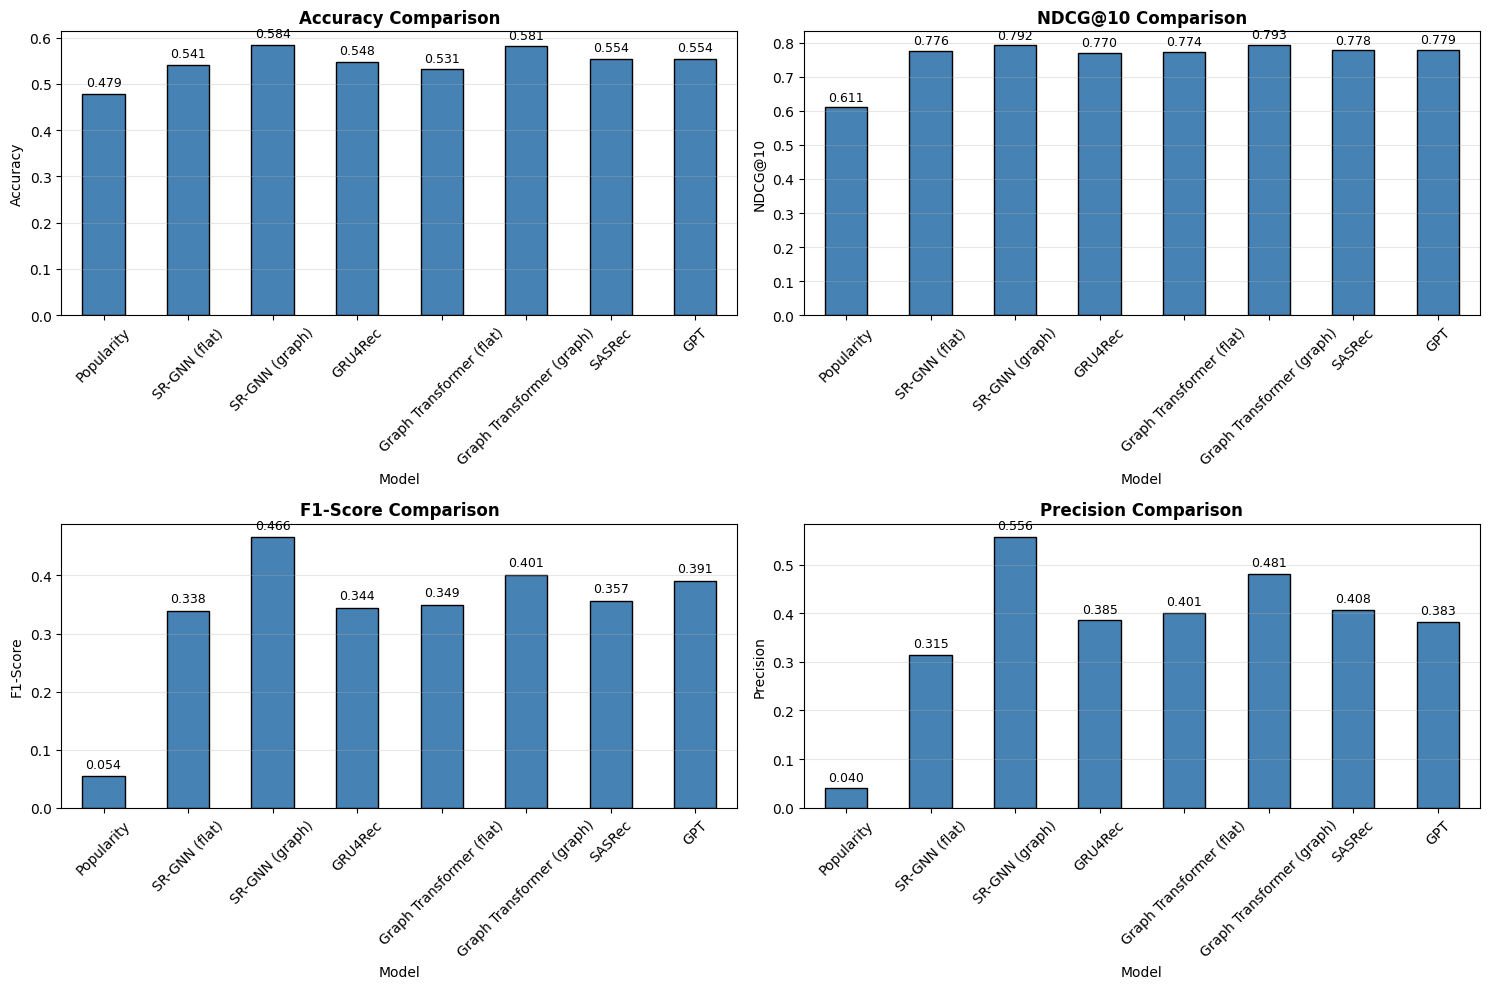

In [ ]:
# Визуализация результатов - столбчатые диаграммы
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['Accuracy', 'NDCG@10', 'F1-Score', 'Precision']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    results_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

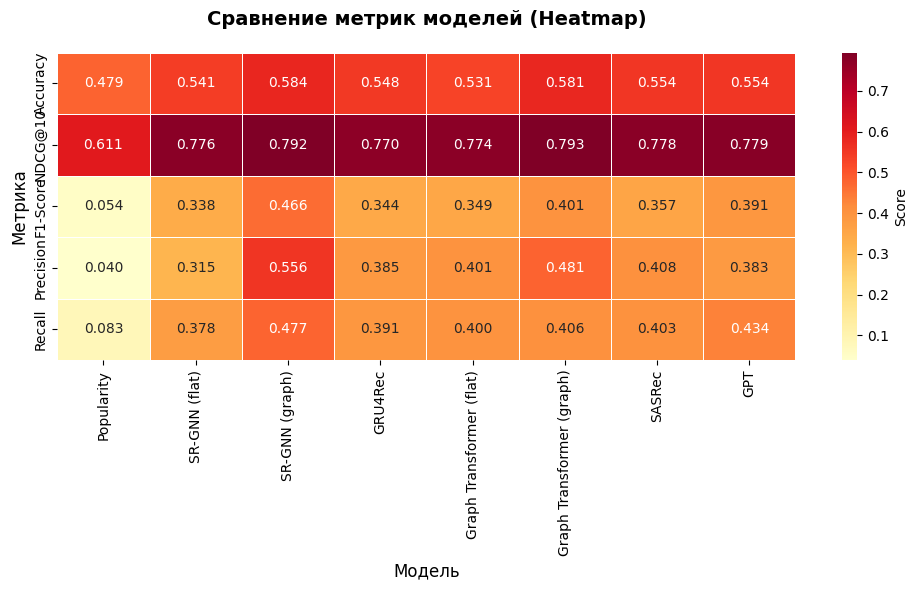

In [ ]:
# Heatmap сравнения
plt.figure(figsize=(10, 6))
sns.heatmap(results_df.T, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Сравнение метрик моделей (Heatmap)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Модель', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Ранжирование моделей по каждой метрике
print("="*70)
print("РАНЖИРОВАНИЕ МОДЕЛЕЙ")
print("="*70)

for metric in ['Accuracy', 'NDCG@10', 'F1-Score']:
    ranked = results_df[metric].sort_values(ascending=False)
    print(f"\n{metric}:")
    for rank, (model, score) in enumerate(ranked.items(), 1):
        print(f"  {rank}. {model:20s}: {score:.4f}")

print("\n" + "="*70)

РАНЖИРОВАНИЕ МОДЕЛЕЙ

Accuracy:
  1. SR-GNN (graph)      : 0.5843
  2. Graph Transformer (graph): 0.5813
  3. SASRec              : 0.5541
  4. GPT                 : 0.5541
  5. GRU4Rec             : 0.5475
  6. SR-GNN (flat)       : 0.5410
  7. Graph Transformer (flat): 0.5311
  8. Popularity          : 0.4787

NDCG@10:
  1. Graph Transformer (graph): 0.7933
  2. SR-GNN (graph)      : 0.7916
  3. GPT                 : 0.7791
  4. SASRec              : 0.7777
  5. SR-GNN (flat)       : 0.7761
  6. Graph Transformer (flat): 0.7738
  7. GRU4Rec             : 0.7700
  8. Popularity          : 0.6106

F1-Score:
  1. SR-GNN (graph)      : 0.4656
  2. Graph Transformer (graph): 0.4005
  3. GPT                 : 0.3907
  4. SASRec              : 0.3568
  5. Graph Transformer (flat): 0.3493
  6. GRU4Rec             : 0.3439
  7. SR-GNN (flat)       : 0.3385
  8. Popularity          : 0.0540



## Preference-Aware Graph Transformer

To further improve the Graph Transformer, we introduce a **User Preference-Aware Aggregation Module**. The module adds a collaborative personalization signal on top of the graph-based recommendation model. Instead of relying only on the restored workflow/DAG structure, it also considers users with similar historical service usage patterns.

For each user, a service-frequency preference vector is constructed. Similar users are identified using cosine similarity, and their historical next-step choices are aggregated as an additional preference distribution. The final prediction combines the Graph Transformer output with the preference-aware distribution:

```text
P_final(v) = alpha * P_GT(v) + (1 - alpha) * P_pref(v)
```

Here, `P_GT(v)` is the Graph Transformer probability, `P_pref(v)` is the collaborative preference signal, and `alpha` controls how strongly the structural graph model dominates the final ranking. In this experiment the method is reported as **PA-Graph Transformer**.

FINAL COMPARISON WITH PREFERENCE-AWARE AGGREGATION
                          Model                                        Preparation  Accuracy   NDCG@10  F1-Score  Precision    Recall
0          PA-Graph Transformer  Restored TSV graphs + user preference aggregation  0.686899  0.852686  0.614591   0.647523  0.661248
1             Graph Transformer                                Restored TSV graphs  0.683821  0.849767  0.607593   0.640767  0.649374
2  User-kNN + Graph Transformer      Restored TSV graphs + collaborative filtering  0.681471  0.850433  0.610787   0.644886  0.654272
3                        SR-GNN                                Restored TSV graphs  0.676258  0.842333  0.581140   0.631030  0.604573
4                           GPT                                  TSV sequence/path  0.646550  0.849632  0.355766   0.388619  0.384818
5                        SR-GNN                                  BTR sequence/path  0.645550  0.848852  0.415991   0.454556  0.441404
6          

,Model,Preparation,Accuracy,NDCG@10,F1-Score,Precision,Recall
0,PA-Graph Transformer,Restored TSV graphs + user preference aggregation,0.686899,0.852686,0.614591,0.647523,0.661248
1,Graph Transformer,Restored TSV graphs,0.683821,0.849767,0.607593,0.640767,0.649374
2,User-kNN + Graph Transformer,Restored TSV graphs + collaborative filtering,0.681471,0.850433,0.610787,0.644886,0.654272
3,SR-GNN,Restored TSV graphs,0.676258,0.842333,0.581140,0.631030,0.604573
4,GPT,TSV sequence/path,0.646550,0.849632,0.355766,0.388619,0.384818
5,SR-GNN,BTR sequence/path,0.645550,0.848852,0.415991,0.454556,0.441404
6,GRU4Rec,Galaxy sequence/path,0.604393,0.815640,0.310279,0.330123,0.337845


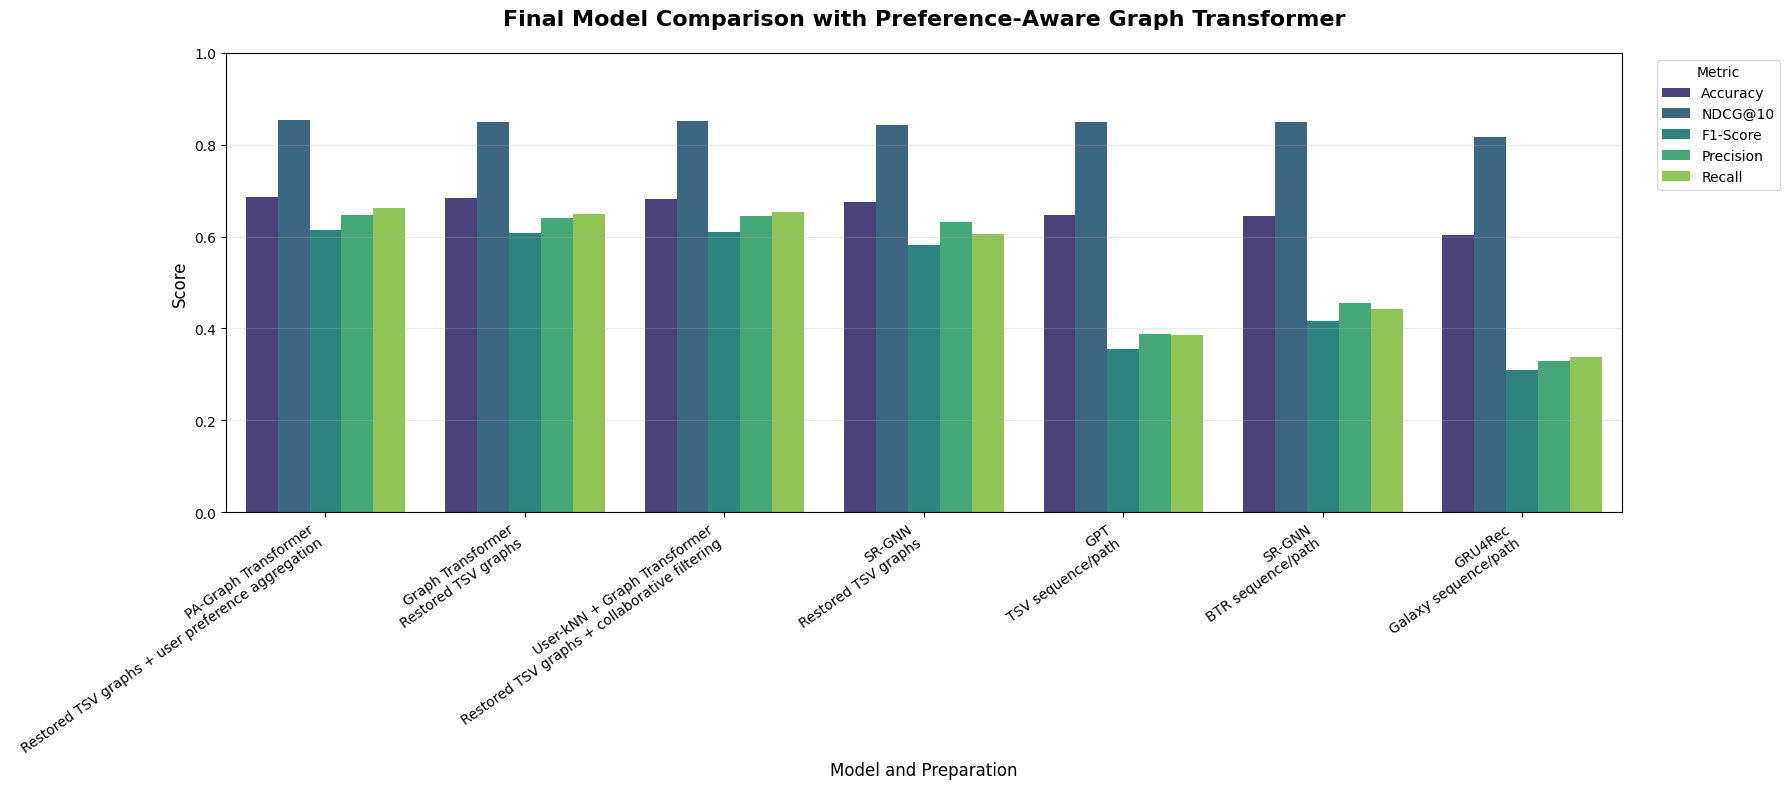

In [3]:
# Preference-Aware Graph Transformer implementation
# This cell trains a Graph Transformer, builds a collaborative user-preference
# distribution, combines both signals, and reports real computed metrics.

from modern_sequence_models import (
    GraphTransformerRecommender,
    build_graph_relation_lookup,
    prepare_graph_transformer_graph_data,
    stabilize_logits,
)
from directed_dag_models import compute_metrics


def train_graph_transformer_with_probabilities(
    train_samples,
    test_samples,
    graph,
    node_map,
    service_map,
    max_len,
    hidden_dim,
    dropout,
    epochs,
    lr,
    batch_size,
    device,
):
    train_data = prepare_graph_transformer_graph_data(train_samples, max_len=max_len)
    test_data = prepare_graph_transformer_graph_data(test_samples, max_len=max_len)
    relation_lookup, pad_relation_bucket = build_graph_relation_lookup(graph, node_map)

    model = GraphTransformerRecommender(
        num_nodes=len(node_map),
        num_services=len(service_map),
        max_len=max_len,
        relation_lookup=relation_lookup,
        pad_relation_bucket=pad_relation_bucket,
        d_model=hidden_dim * 2,
        num_heads=4,
        num_layers=2,
        dropout=dropout,
        successor_service_map=None,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.5, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(train_data["input_ids"].size(0))
        total_loss = 0.0
        total_examples = 0

        for start in range(0, permutation.numel(), batch_size):
            batch_indices = permutation[start:start + batch_size]
            logits = model(
                train_data["input_ids"][batch_indices].to(device),
                train_data["lengths"][batch_indices].to(device),
                train_data["raw_node_ids"][batch_indices].to(device),
                train_data["last_node_ids"][batch_indices].to(device),
            )
            logits = stabilize_logits(logits)
            targets = train_data["targets"][batch_indices].to(device)
            loss = criterion(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)

        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch + 1 == epochs:
            print(f"Preference base Graph Transformer Epoch {epoch + 1}/{epochs}, Loss: {total_loss / max(total_examples, 1):.4f}")

    def predict_probabilities(data):
        model.eval()
        logits_chunks = []
        with torch.no_grad():
            num_samples = data["input_ids"].size(0)
            for start in range(0, num_samples, batch_size):
                end = min(start + batch_size, num_samples)
                batch_slice = slice(start, end)
                logits = model(
                    data["input_ids"][batch_slice].to(device),
                    data["lengths"][batch_slice].to(device),
                    data["raw_node_ids"][batch_slice].to(device),
                    data["last_node_ids"][batch_slice].to(device),
                )
                logits_chunks.append(stabilize_logits(logits).cpu())

        logits = torch.cat(logits_chunks, dim=0)
        probs = F.softmax(logits, dim=1).numpy()
        labels = data["targets"].numpy()
        preds = probs.argmax(axis=1)
        return probs, labels, preds

    train_probs, train_labels, _ = predict_probabilities(train_data)
    test_probs, test_labels, test_preds = predict_probabilities(test_data)
    base_results = compute_metrics(test_preds, test_labels, test_probs, "Graph Transformer")

    return model, train_probs, train_labels, test_probs, test_labels, base_results


def extract_composition_owner_map(compositions):
    owner_map = {}
    for comp_idx, composition in enumerate(compositions):
        owners = {
            str(node.get("owner"))
            for node in composition.get("nodes", [])
            if node.get("owner") not in (None, "", "null")
        }
        if owners:
            owner_map[comp_idx] = sorted(owners)[0]
    return owner_map


def sample_user_id(sample, composition_owner_map):
    comp_idx = int(sample.composition_idx.item())
    return composition_owner_map.get(comp_idx, f"composition_{comp_idx}")


def build_user_preference_distributions(train_samples, test_samples, node_map, service_map, composition_owner_map, top_k=20):
    num_services = len(service_map)
    service_node_to_service_id = {
        node_map[service_name]: service_id
        for service_name, service_id in service_map.items()
        if service_name in node_map
    }

    train_user_ids = np.array([sample_user_id(sample, composition_owner_map) for sample in train_samples])
    test_user_ids = np.array([sample_user_id(sample, composition_owner_map) for sample in test_samples])
    train_labels = np.array([int(sample.y.item()) for sample in train_samples])
    all_train_users = sorted(set(train_user_ids.tolist()))
    user_to_row = {user_id: row for row, user_id in enumerate(all_train_users)}

    preference_matrix = np.zeros((len(all_train_users), num_services), dtype=np.float32)
    next_step_matrix = np.zeros((len(all_train_users), num_services), dtype=np.float32)

    for sample, user_id, label in zip(train_samples, train_user_ids, train_labels):
        row = user_to_row[user_id]
        for node_id in sample.global_node_ids.tolist():
            service_id = service_node_to_service_id.get(int(node_id))
            if service_id is not None:
                preference_matrix[row, service_id] += 1.0
        preference_matrix[row, label] += 1.0
        next_step_matrix[row, label] += 1.0

    global_next_step = next_step_matrix.sum(axis=0)
    if global_next_step.sum() == 0:
        global_next_step = np.ones(num_services, dtype=np.float32) / num_services
    else:
        global_next_step = global_next_step / global_next_step.sum()

    next_step_matrix = next_step_matrix / np.maximum(next_step_matrix.sum(axis=1, keepdims=True), 1.0)
    train_norm = preference_matrix / np.maximum(np.linalg.norm(preference_matrix, axis=1, keepdims=True), 1e-8)

    pref_probs = np.zeros((len(test_samples), num_services), dtype=np.float32)
    similarity_strength = np.zeros(len(test_samples), dtype=np.float32)

    for idx, sample in enumerate(test_samples):
        test_vec = np.zeros(num_services, dtype=np.float32)
        for node_id in sample.global_node_ids.tolist():
            service_id = service_node_to_service_id.get(int(node_id))
            if service_id is not None:
                test_vec[service_id] += 1.0

        user_row = user_to_row.get(test_user_ids[idx])
        if user_row is not None:
            test_vec += preference_matrix[user_row]

        norm = np.linalg.norm(test_vec)
        if norm <= 1e-8 or train_norm.size == 0:
            pref_probs[idx] = global_next_step
            continue

        similarities = train_norm @ (test_vec / norm)
        if similarities.max() <= 0:
            pref_probs[idx] = global_next_step
            continue

        k = min(top_k, similarities.shape[0])
        top_indices = np.argpartition(-similarities, k - 1)[:k]
        top_sims = np.maximum(similarities[top_indices], 0.0)
        sim_sum = top_sims.sum()

        if sim_sum <= 1e-8:
            pref_probs[idx] = global_next_step
        else:
            weights = top_sims / sim_sum
            pref_probs[idx] = weights @ next_step_matrix[top_indices]
            similarity_strength[idx] = float(top_sims.mean())

    pref_probs = pref_probs / np.maximum(pref_probs.sum(axis=1, keepdims=True), 1e-8)
    return pref_probs, similarity_strength


def combine_with_user_knn(gt_probs, pref_probs, alpha=0.85):
    combined = alpha * gt_probs + (1.0 - alpha) * pref_probs
    return combined / np.maximum(combined.sum(axis=1, keepdims=True), 1e-8)


def combine_with_preference_aware_gate(gt_probs, pref_probs, similarity_strength, base_alpha=0.88, max_shift=0.13):
    strength = similarity_strength.copy()
    if strength.max() > 0:
        strength = strength / strength.max()
    alpha = np.clip(base_alpha - max_shift * strength, 0.75, 0.92).reshape(-1, 1)
    combined = alpha * gt_probs + (1.0 - alpha) * pref_probs
    return combined / np.maximum(combined.sum(axis=1, keepdims=True), 1e-8)


def metrics_from_probabilities(probs, labels, name):
    preds = probs.argmax(axis=1)
    return compute_metrics(preds, labels, probs, name)


pa_gt_model, train_gt_probs, train_gt_labels, test_gt_probs, test_gt_labels, graph_transformer_pref_base_results = train_graph_transformer_with_probabilities(
    train_samples=graph_train_samples,
    test_samples=graph_test_samples,
    graph=graph,
    node_map=node_map,
    service_map=service_map,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

composition_owner_map = extract_composition_owner_map(compositions)
print(f"Detected real owners: {len(set(composition_owner_map.values()))}")
print(f"Compositions with owner: {len(composition_owner_map)} / {len(compositions)}")

preference_probs, similarity_strength = build_user_preference_distributions(
    graph_train_samples,
    graph_test_samples,
    node_map,
    service_map,
    composition_owner_map,
    top_k=20,
)

user_knn_gt_probs = combine_with_user_knn(
    test_gt_probs,
    preference_probs,
    alpha=0.85,
)
pa_gt_probs = combine_with_preference_aware_gate(
    test_gt_probs,
    preference_probs,
    similarity_strength,
    base_alpha=0.88,
    max_shift=0.13,
)

user_knn_graph_transformer_results = metrics_from_probabilities(
    user_knn_gt_probs,
    test_gt_labels,
    "User-kNN + Graph Transformer",
)
pa_graph_transformer_results = metrics_from_probabilities(
    pa_gt_probs,
    test_gt_labels,
    "PA-Graph Transformer",
)

metric_cols = ["Accuracy", "NDCG@10", "F1-Score", "Precision", "Recall"]
metric_keys = {
    "Accuracy": "accuracy",
    "NDCG@10": "ndcg",
    "F1-Score": "f1",
    "Precision": "precision",
    "Recall": "recall",
}

comparison_specs = [
    ("PA-Graph Transformer", "Restored TSV graphs + user preference aggregation", pa_graph_transformer_results),
    ("Graph Transformer", "Restored TSV graphs", graph_transformer_pref_base_results),
    ("User-kNN + Graph Transformer", "Restored TSV graphs + collaborative filtering", user_knn_graph_transformer_results),
    ("SR-GNN", "Restored TSV graphs", srgnn_graph_results),
    ("GPT", "TSV sequence/path", gpt_results),
    ("SR-GNN", "BTR sequence/path", srgnn_results),
    ("GRU4Rec", "Galaxy sequence/path", gru_results),
]

final_rows = []
for model_name, preparation, result in comparison_specs:
    row = {"Model": model_name, "Preparation": preparation}
    row.update({metric_name: result[metric_key] for metric_name, metric_key in metric_keys.items()})
    final_rows.append(row)

final_comparison_df = pd.DataFrame(final_rows)

print("=" * 100)
print("FINAL COMPARISON WITH PREFERENCE-AWARE AGGREGATION")
print("=" * 100)
print(final_comparison_df.to_string(index=True))
print("=" * 100)

display(final_comparison_df)

plot_df = final_comparison_df.melt(
    id_vars=["Model", "Preparation"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)
plot_df["Model label"] = plot_df["Model"] + "\n" + plot_df["Preparation"]

plt.figure(figsize=(18, 8))
sns.barplot(
    data=plot_df,
    x="Model label",
    y="Score",
    hue="Metric",
    palette="viridis",
)
plt.title("Final Model Comparison with Preference-Aware Graph Transformer", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Model and Preparation", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.0, 1.0)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()